This notebook explores the internal architecture of the Community-1 speaker diarization pipeline. 

- Starting from the HuggingFace pipeline object, we progressively unwrap its components: the PyanNet segmentater and the WeSpeakerResNet34 embedder 
- inspecting their structure, input/output shapes, and data flow. We run dummy inference to validate our understanding before building anything production-ready.

In [1]:
import os
import dotenv

dotenv.load_dotenv("..")
HUGGINGFACE_ACCESS_TOKEN = os.getenv("HF_TOKEN")

In [ ]:
from pyannote.audio import Pipeline

pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization-community-1", token=HUGGINGFACE_ACCESS_TOKEN)

In [ ]:
# run the pipeline locally on your computer
output = pipeline("../audio/debate.wav")

In [4]:
# print the predicted speaker diarization 
for turn, speaker in output.speaker_diarization:
    print(f"{speaker} speaks between t={turn.start:.3f}s and t={turn.end:.3f}s")


SPEAKER_00 speaks between t=0.031s and t=0.655s
SPEAKER_00 speaks between t=0.672s and t=19.977s
SPEAKER_01 speaks between t=1.938s and t=1.988s
SPEAKER_01 speaks between t=4.503s and t=4.655s
SPEAKER_01 speaks between t=5.178s and t=6.916s
SPEAKER_01 speaks between t=7.895s and t=8.165s
SPEAKER_01 speaks between t=10.257s and t=11.320s
SPEAKER_01 speaks between t=11.388s and t=12.417s
SPEAKER_01 speaks between t=12.552s and t=16.231s
SPEAKER_01 speaks between t=16.332s and t=16.990s
SPEAKER_01 speaks between t=18.070s and t=18.745s
SPEAKER_01 speaks between t=18.914s and t=19.370s


### 1. Quick review of the data structure produced py the pipeline

In [ ]:
[value for value in  dir(output) if not value.startswith("__") ]

['exclusive_speaker_diarization',
 'serialize',
 'speaker_diarization',
 'speaker_embeddings']

In [6]:
output.speaker_embeddings.shape

(2, 256)

In [9]:
output.serialize()

{'diarization': [{'start': 0.031, 'end': 0.655, 'speaker': 'SPEAKER_00'},
  {'start': 0.672, 'end': 19.977, 'speaker': 'SPEAKER_00'},
  {'start': 1.938, 'end': 1.988, 'speaker': 'SPEAKER_01'},
  {'start': 4.503, 'end': 4.655, 'speaker': 'SPEAKER_01'},
  {'start': 5.178, 'end': 6.916, 'speaker': 'SPEAKER_01'},
  {'start': 7.895, 'end': 8.165, 'speaker': 'SPEAKER_01'},
  {'start': 10.257, 'end': 11.32, 'speaker': 'SPEAKER_01'},
  {'start': 11.388, 'end': 12.417, 'speaker': 'SPEAKER_01'},
  {'start': 12.552, 'end': 16.231, 'speaker': 'SPEAKER_01'},
  {'start': 16.332, 'end': 16.99, 'speaker': 'SPEAKER_01'},
  {'start': 18.07, 'end': 18.745, 'speaker': 'SPEAKER_01'},
  {'start': 18.914, 'end': 19.37, 'speaker': 'SPEAKER_01'}],
 'exclusive_diarization': [{'start': 0.031,
   'end': 0.655,
   'speaker': 'SPEAKER_00'},
  {'start': 0.672, 'end': 19.977, 'speaker': 'SPEAKER_00'}]}

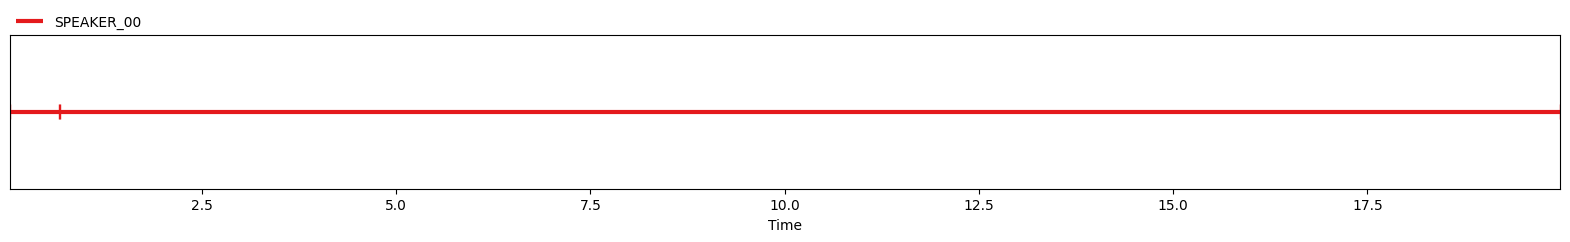

In [11]:
output.exclusive_speaker_diarization

### 2. Quick review of model components

In [20]:
from torchinfo import summary

In [12]:
print(type(pipeline))
print(pipeline.__class__.__module__)

<class 'pyannote.audio.pipelines.speaker_diarization.SpeakerDiarization'>
pyannote.audio.pipelines.speaker_diarization


In [15]:
sorted(pipeline.__dict__.keys())

['_audio',
 '_expects_num_speakers',
 '_inferences',
 '_instantiated',
 '_models',
 '_otel_name',
 '_otel_origin',
 '_parameters',
 '_pipelines',
 '_plda',
 '_training',
 'der_variant',
 'embedding',
 'embedding_batch_size',
 'embedding_exclude_overlap',
 'klustering',
 'legacy',
 'plda',
 'segmentation_model',
 'segmentation_step']

In [17]:
# Understand the sub-models fully
for k, v in pipeline._models.items():
    print(k, type(v))

In [18]:

for k, v in pipeline._inferences.items():
    print(k, type(v))

_segmentation <class 'pyannote.audio.core.inference.Inference'>
_embedding <class 'pyannote.audio.pipelines.speaker_verification.PyannoteAudioPretrainedSpeakerEmbedding'>


In [ ]:
seg_inference = pipeline._inferences['_segmentation']
print(type(seg_inference))
dir(seg_inference)

In [31]:
print(type(seg_inference.model))
summary(seg_inference.model)

<class 'pyannote.audio.models.segmentation.PyanNet.PyanNet'>


Layer (type:depth-idx)                   Param #
PyanNet                                  --
├─SincNet: 1-1                           --
│    └─InstanceNorm1d: 2-1               2
│    └─ModuleList: 2-2                   --
│    │    └─Encoder: 3-1                 80
│    │    └─Conv1d: 3-2                  24,060
│    │    └─Conv1d: 3-3                  18,060
│    └─ModuleList: 2-3                   --
│    │    └─MaxPool1d: 3-4               --
│    │    └─MaxPool1d: 3-5               --
│    │    └─MaxPool1d: 3-6               --
│    └─ModuleList: 2-4                   --
│    │    └─InstanceNorm1d: 3-7          160
│    │    └─InstanceNorm1d: 3-8          120
│    │    └─InstanceNorm1d: 3-9          120
├─LSTM: 1-2                              1,380,352
├─ModuleList: 1-3                        --
│    └─Linear: 2-5                       32,896
│    └─Linear: 2-6                       16,512
├─Linear: 1-4                            903
├─LogSoftmax: 1-5                        --
T

In [ ]:
emb_inference = pipeline._inferences['_embedding']
print(type(emb_inference))
dir(emb_inference)

In [33]:
emb_model = pipeline._inferences['_embedding'].model_
print(type(emb_model))
summary(emb_model)

<class 'pyannote.audio.models.embedding.wespeaker.WeSpeakerResNet34'>


Layer (type:depth-idx)                        Param #
WeSpeakerResNet34                             --
├─ResNet: 1-1                                 --
│    └─Conv2d: 2-1                            288
│    └─BatchNorm2d: 2-2                       64
│    └─Sequential: 2-3                        --
│    │    └─BasicBlock: 3-1                   18,560
│    │    └─BasicBlock: 3-2                   18,560
│    │    └─BasicBlock: 3-3                   18,560
│    └─Sequential: 2-4                        --
│    │    └─BasicBlock: 3-4                   57,728
│    │    └─BasicBlock: 3-5                   73,984
│    │    └─BasicBlock: 3-6                   73,984
│    │    └─BasicBlock: 3-7                   73,984
│    └─Sequential: 2-5                        --
│    │    └─BasicBlock: 3-8                   230,144
│    │    └─BasicBlock: 3-9                   295,424
│    │    └─BasicBlock: 3-10                  295,424
│    │    └─BasicBlock: 3-11                  295,424
│    │    └─Bas